# Market Regime GMM vs HMM - Factor Returns

This notebook keeps the same workflow as `market_regime_GMMvsHMM.ipynb`, but uses the intuitive factor clusters from `1.cleaned_return_df.csv`.

Main rule:
- Fit GMM/HMM on z-scored factor returns.
- Interpret regimes with raw factor returns on the same dates.


In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys
sys.path.append(str(PROJECT_ROOT))


## 1. Load Settings


In [47]:
from src.config import COVARIANCE_TYPE, RANDOM_STATE

DATA_FILE = PROJECT_ROOT / "Data" / "1.cleaned_return_df.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "factor_regime_model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANNUALIZATION = 365
ROLLING_WINDOW = 365


## 2. Load Cleaned Data and Build Raw Factor Returns

The cleaned file is calendar-daily. Weekend rows are present but carry zero/NaN returns, so this notebook uses 365 for annualized interpretation.


In [48]:
factor_clusters = {
    "Equity": [
        "dm_stock", "MSCI World Gross", "MSCI World", "MSCI World Value",
        "MSCI_All Country World", "MSCI World Real Estate", "SNP global infrastructure",
    ],
    "Interest_Rate": [
        "fixed_income", "Bloomberg Barclays Global AGG", "Bloomberg Barclays US AGG",
        "Bloomberg Barclays US 1-3 month treasury", "Bloomberg US 20+ Treasury",
        "Bloomberg US 7-10 Treasury", "ICE US 20+ TREASURY", "ICE US 7-10  TREASURY",
    ],
    "Credit": [
        "Bloomberg Barclays US ABS", "Bloomberg Barclays US Corp HY",
        "Bloomberg Barclays US Corp IG", "Bloomberg Barclays US Long Gov credit",
    ],
    "Commodities": [
        "commodity", "SNP GSCI TR", "SNP metal and mining",
        "SNP oil gas exploration and production",
    ],
    "Emerging_Market": ["em_stock", "MSCI Emerging", "Bloomberg Barclays EM AGG"],
    "Foreign_Currency": ["MSCI World x US", "Bloomberg Barclays Global AGG"],
    "Local_Inflation": [
        "Bloomberg Barclays US Inflation Protected",
        "Bloomberg Barclays US Inflation Protected 7-10 year",
    ],
    "Local_Equity": ["Russel 300 TR"],
}

cleaned = pd.read_csv(DATA_FILE, parse_dates=["Date"]).set_index("Date").sort_index()
asset_returns = cleaned.apply(pd.to_numeric, errors="coerce")

raw_factor_returns = pd.DataFrame(index=asset_returns.index)
for factor, columns in factor_clusters.items():
    available = [column for column in columns if column in asset_returns.columns]
    raw_factor_returns[factor] = asset_returns[available].mean(axis=1, skipna=True)

raw_factor_returns = raw_factor_returns.dropna(how="any")
# raw_factor_returns.to_csv(OUTPUT_DIR / "raw_factor_returns_equal_weighted.csv")
raw_factor_returns.tail()


,Equity,Interest_Rate,Credit,Commodities,Emerging_Market,Foreign_Currency,Local_Inflation,Local_Equity
Date,,,,,,,,
2021-11-22,-0.005277,-0.007039,-0.004604,0.011730,-0.005037,-0.006494,-0.008512,-0.004631
2021-11-23,0.000631,-0.005223,-0.005810,0.018745,-0.005260,-0.005058,-0.004248,0.000501
2021-11-24,0.002084,0.003484,0.003234,0.002677,-0.000965,-0.003431,0.003762,0.002892
2021-11-25,0.001224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-11-26,-0.010202,0.009653,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 3. Standardize for Model Fitting

The GMM/HMM gets `scaled_returns`. All economic interpretation later uses `raw_factor_returns` with the same index.


In [49]:
from src.features import cumulative_returns, standardize_returns

scaled_returns, scaler = standardize_returns(raw_factor_returns)
raw_factor_returns = raw_factor_returns.loc[scaled_returns.index]

# scaled_returns.to_csv(OUTPUT_DIR / "zscored_factor_returns_for_model.csv")
scaled_returns.describe().T[["mean", "std", "min", "max"]].round(4)


,mean,std,min,max
Equity,0.0,1.0001,-12.6226,11.2498
Interest_Rate,-0.0,1.0001,-9.9436,7.9490
Credit,-0.0,1.0001,-15.0802,7.1058
Commodities,-0.0,1.0001,-12.3169,9.6626
Emerging_Market,0.0,1.0001,-9.9605,10.5690
Foreign_Currency,0.0,1.0001,-12.4140,11.7978
Local_Inflation,0.0,1.0001,-10.8004,13.5134
Local_Equity,0.0,1.0001,-11.9403,11.0713


## GMM Model Selection


In [50]:
from src.gmm_model import gmm_model_selection
from src.plots import plot_model_selection

component_range = range(2, 7)
gmm_selection = gmm_model_selection(
    scaled_returns,
    component_range=component_range,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)

# Use BIC component count
BIC_N_COMPONENTS = int(gmm_selection["BIC"].idxmin())
N_COMPONENTS = BIC_N_COMPONENTS
print(f"Using BIC-selected n_components = {N_COMPONENTS}")
gmm_selection.round(2)


Using BIC-selected n_components = 6


,AIC,BIC
n_components,,
2,-114927.93,-114295.22
3,-130337.78,-129385.17
4,-133112.47,-131839.94
5,-137399.02,-135806.58
6,-137777.42,-135865.08


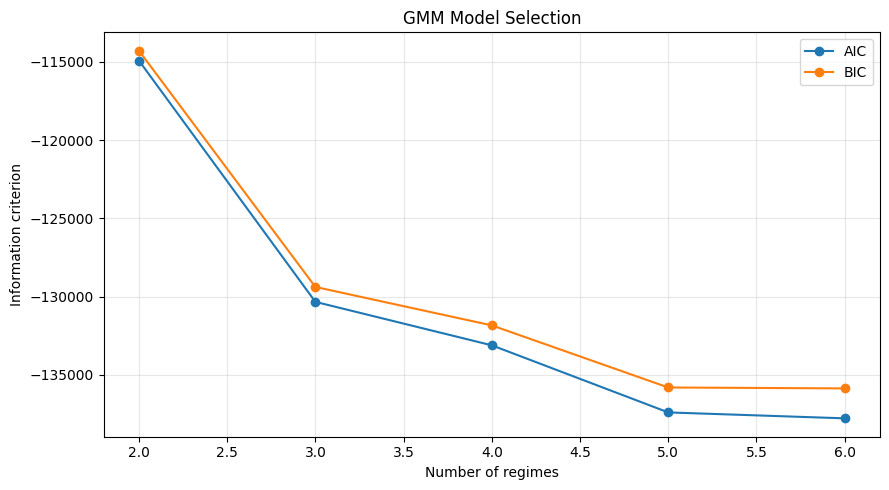

In [51]:
plot_model_selection(gmm_selection);


## 4. Fit the GMM


In [52]:
from src.gmm_model import fit_gmm_regimes, validate_regime_outputs

gmm, labels, probabilities = fit_gmm_regimes(
    scaled_returns,
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)
validate_regime_outputs(raw_factor_returns, labels, probabilities, N_COMPONENTS)
labels.value_counts().sort_index()


Regime
0     222
1    2590
2    2143
3    2343
4     806
5     933
Name: count, dtype: int64

## 5. Cumulative Return Chart


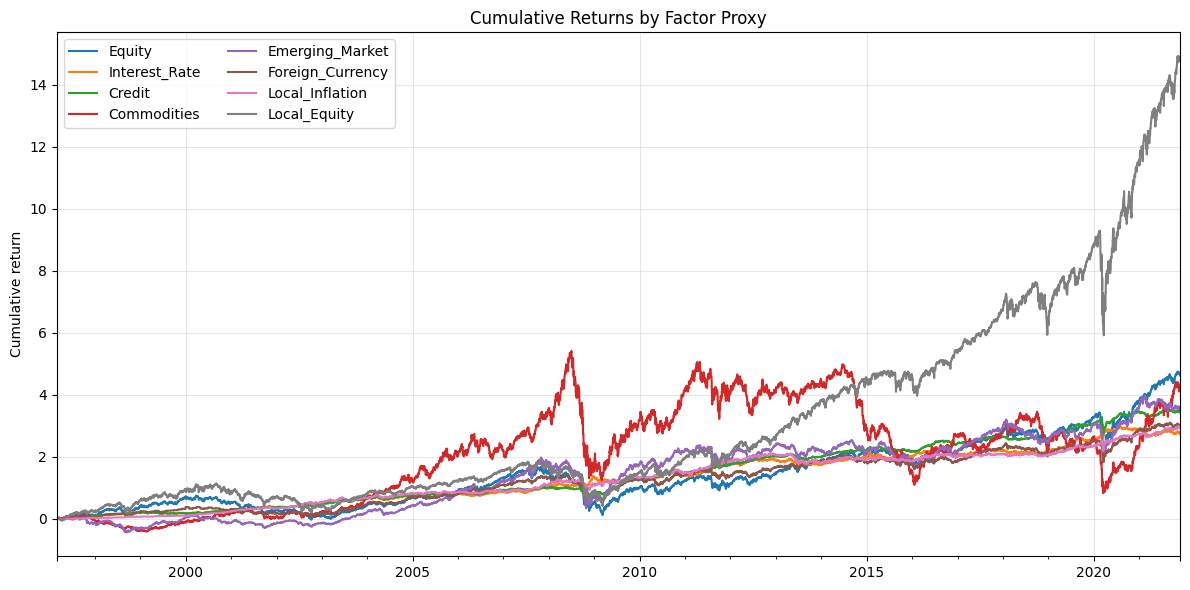

In [53]:
from src.plots import plot_cumulative_returns

cum_returns = cumulative_returns(raw_factor_returns)
plot_cumulative_returns(raw_factor_returns);


## 6. Equity Colored by Regime


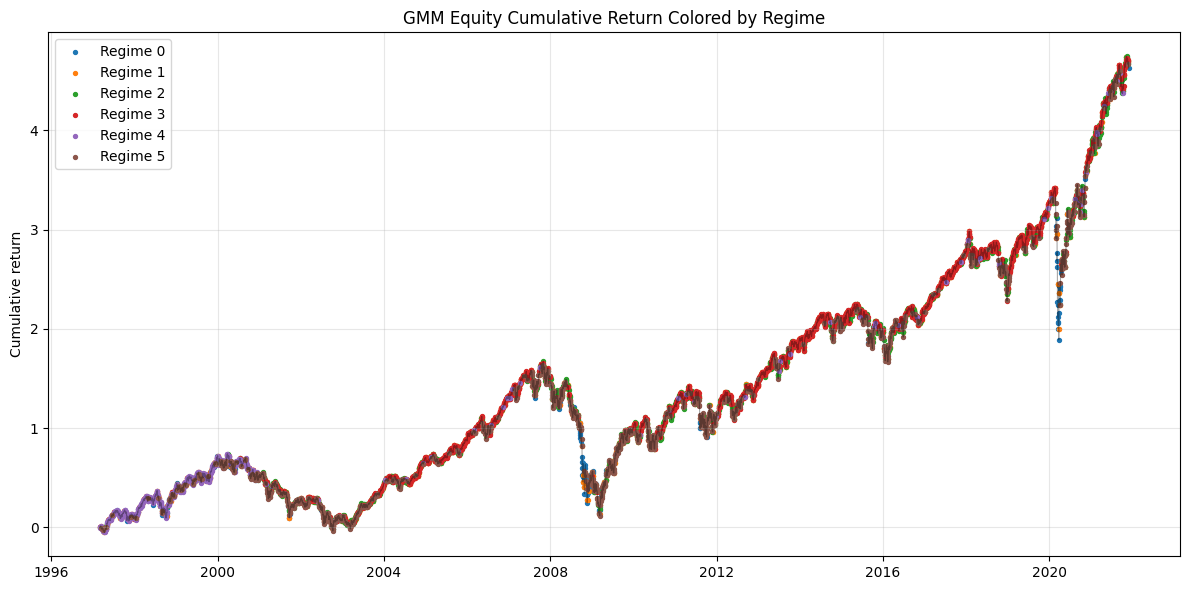

In [54]:
from src.plots import plot_regime_colored_series

plot_regime_colored_series(cum_returns, labels, column="Equity");


## 7. Regime Probability Chart


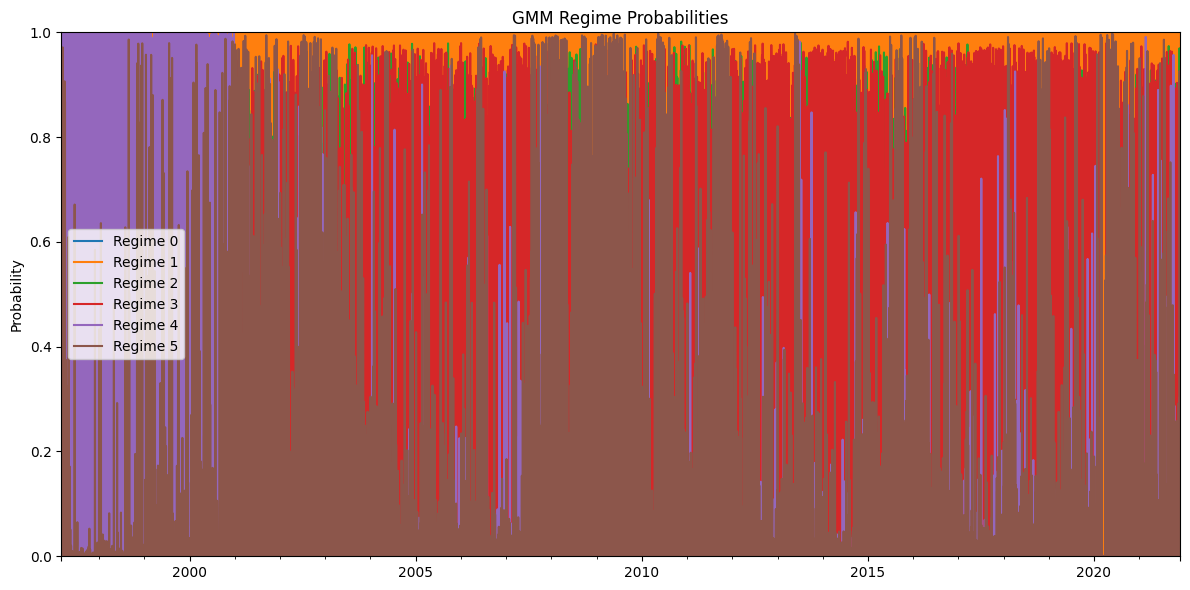

In [55]:
from src.plots import plot_regime_probabilities

plot_regime_probabilities(probabilities);


## 8. Regime Statistics Interpreted with Raw Returns


In [56]:
from src.analysis import compact_interpretation_table, regime_correlations

rows = []
for regime in sorted(labels.unique()):
    regime_returns = raw_factor_returns.loc[labels == regime]
    annual_return = regime_returns.mean() * ANNUALIZATION
    annual_volatility = regime_returns.std() * np.sqrt(ANNUALIZATION)
    annual_sharpe = annual_return / annual_volatility.replace(0, np.nan)
    corr = regime_returns.corr()
    mask = ~np.eye(corr.shape[0], dtype=bool)

    rows.append({
        "Regime": regime,
        "Frequency": len(regime_returns) / len(raw_factor_returns),
        "AvgCorrelation": corr.where(mask).stack().mean(),
        **{f"{col}_Return": annual_return[col] for col in raw_factor_returns.columns},
        **{f"{col}_Volatility": annual_volatility[col] for col in raw_factor_returns.columns},
        **{f"{col}_Sharpe": annual_sharpe[col] for col in raw_factor_returns.columns},
    })

summary = pd.DataFrame(rows).set_index("Regime")
# summary.to_csv(OUTPUT_DIR / "gmm_raw_return_regime_summary.csv")
compact_interpretation_table(summary).round(4)


,Frequency,AvgCorrelation,Equity_Return,Credit_Return,Commodities_Return,Equity_Volatility,Equity_Sharpe
Regime,,,,,,,
0,0.0246,0.2989,-0.7265,-0.2135,-0.9770,0.5828,-1.2466
1,0.2866,0.1457,0.0000,0.0000,0.0000,0.0000,0.5794
2,0.2371,0.2903,0.0868,0.0638,0.0839,0.1418,0.6118
3,0.2593,0.2427,0.3956,0.1385,0.4122,0.0692,5.7143
4,0.0892,0.1647,0.2328,0.0850,0.1011,0.1540,1.5117
5,0.1032,0.1442,-0.5449,0.0658,-0.4321,0.2700,-2.0184


## 9. Correlations by Regime


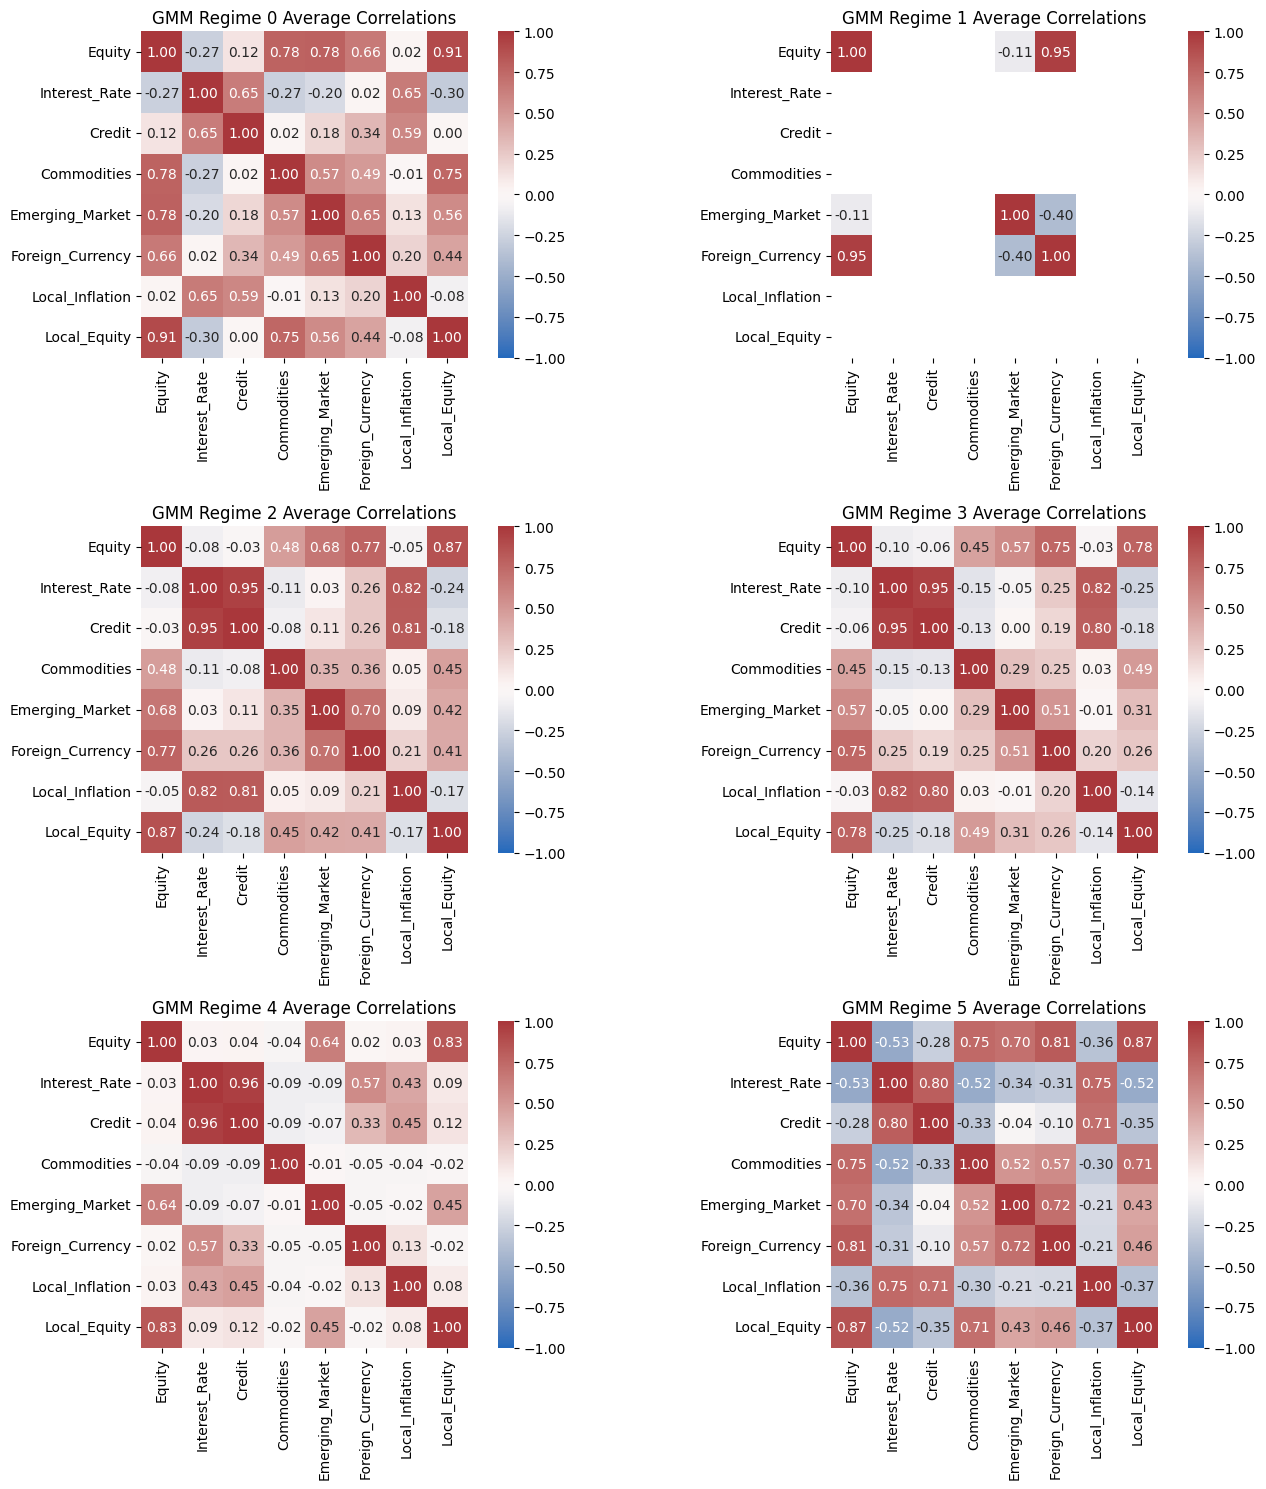

In [57]:
import importlib
import src.plots as plots

plots = importlib.reload(plots)
plot_factor_return_table = plots.plot_factor_return_table
plot_factor_volatility_table = plots.plot_factor_volatility_table
plot_regime_correlation_heatmaps = plots.plot_regime_correlation_heatmaps

gmm_correlations = regime_correlations(raw_factor_returns, labels)
plot_regime_correlation_heatmaps(gmm_correlations);


## 10. Factor Volatility Table


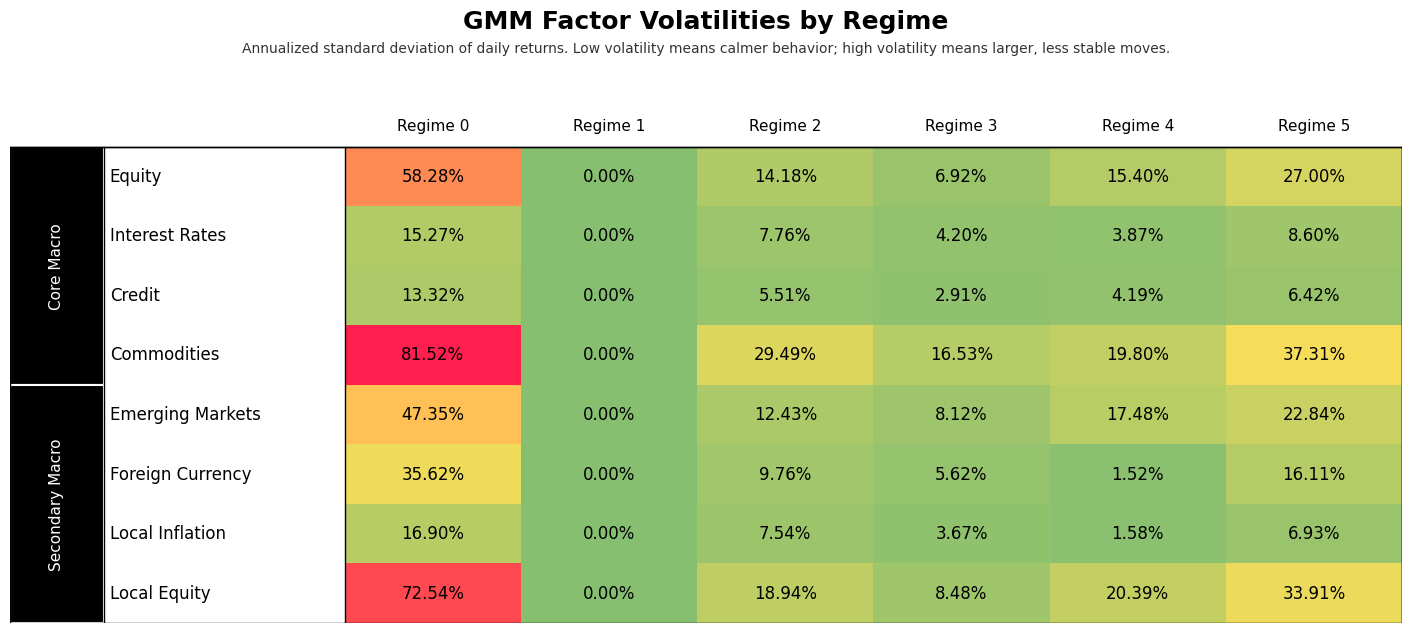

In [58]:
plot_factor_volatility_table(summary);


## 11. Factor Return Table


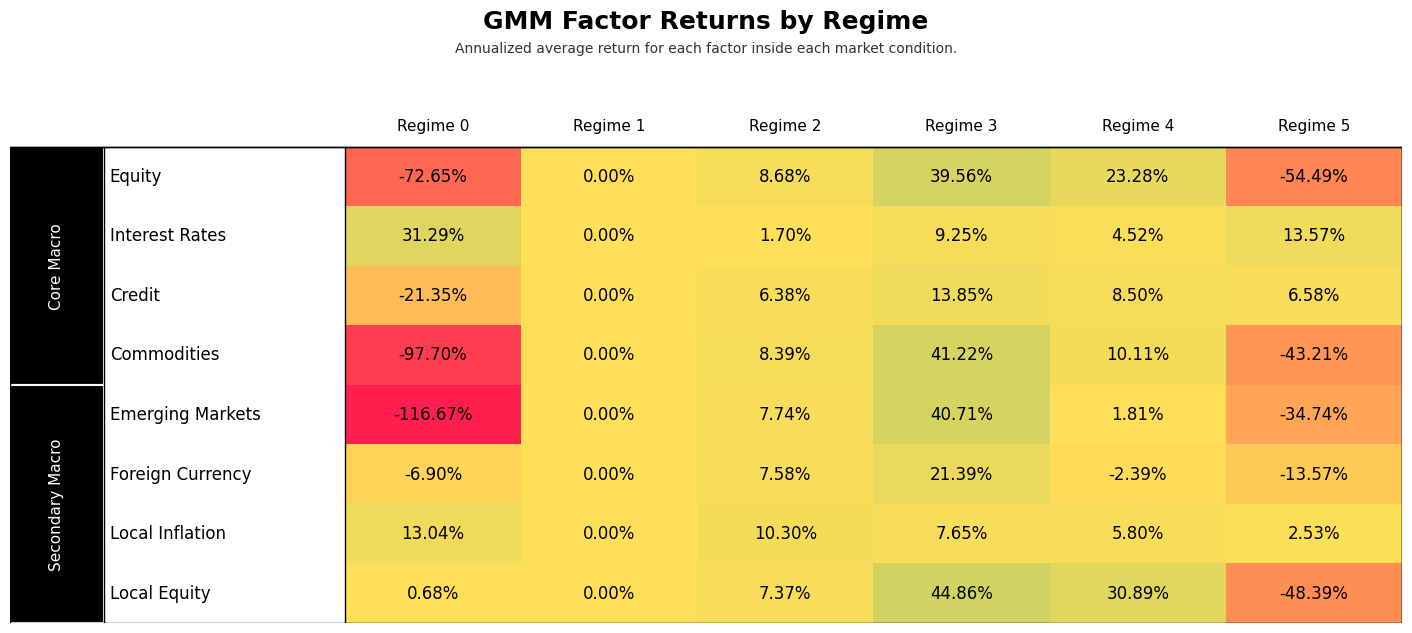

In [59]:
plot_factor_return_table(summary);


## Economic Interpretation Guide

The model was fit on z-scores, so the state assignment is scale-balanced across factors. The regime tables above are raw annualized returns and volatility, so they can be interpreted economically.


## GMM Transition Diagnostics


In [60]:
from src.analysis import regime_duration_stats, regime_performance_summary, transition_matrix
from src.plots import plot_transition_heatmap

gmm_transition_counts = transition_matrix(labels, n_regimes=N_COMPONENTS, normalize=False)
gmm_transition_probabilities = transition_matrix(labels, n_regimes=N_COMPONENTS, normalize=True)
gmm_durations = regime_duration_stats(labels)
gmm_performance = regime_performance_summary(raw_factor_returns, labels, annualization=ANNUALIZATION)

display(gmm_transition_counts.astype(int))
display(gmm_transition_probabilities.round(3))


To,0,1,2,3,4,5
From,,,,,,
0,70,54,11,4,28,54
1,44,1294,375,540,175,162
2,19,435,773,578,50,288
3,6,483,651,1026,77,100
4,37,142,56,83,436,52
5,46,181,277,112,40,277


To,0,1,2,3,4,5
From,,,,,,
0,0.317,0.244,0.050,0.018,0.127,0.244
1,0.017,0.500,0.145,0.208,0.068,0.063
2,0.009,0.203,0.361,0.270,0.023,0.134
3,0.003,0.206,0.278,0.438,0.033,0.043
4,0.046,0.176,0.069,0.103,0.541,0.065
5,0.049,0.194,0.297,0.120,0.043,0.297


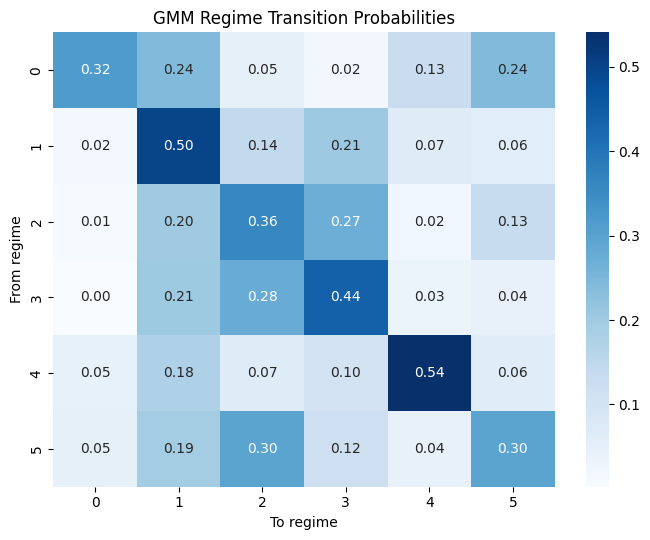

In [61]:
plot_transition_heatmap(
    gmm_transition_probabilities,
    title="GMM Regime Transition Probabilities",
    fmt=".2f",
);


In [62]:
gmm_durations.round(2)


,Count,Mean,Median,Min,Max
Regime,,,,,
0,152,1.46,1.0,1,5
1,1296,2.00,2.0,1,3
2,1370,1.56,1.0,1,5
3,1317,1.78,1.0,1,5
4,370,2.18,1.0,1,5
5,656,1.42,1.0,1,5


In [63]:
gmm_performance.round(4)


,Regime,Factor,AnnualReturn,AnnualVolatility,Sharpe,Observations
0,0,Equity,-0.7265,0.5828,-1.2466,222
1,0,Interest_Rate,0.3129,0.1527,2.0494,222
2,0,Credit,-0.2135,0.1332,-1.6033,222
3,0,Commodities,-0.9770,0.8152,-1.1986,222
4,0,Emerging_Market,-1.1667,0.4735,-2.4642,222
5,0,Foreign_Currency,-0.0690,0.3562,-0.1936,222
6,0,Local_Inflation,0.1304,0.1690,0.7714,222
7,0,Local_Equity,0.0068,0.7254,0.0094,222
8,1,Equity,0.0000,0.0000,0.5794,2590
9,1,Interest_Rate,0.0000,0.0000,NaN,2590


In [64]:
gmm_means = pd.DataFrame(gmm.means_, columns=scaled_returns.columns)
gmm_means.index.name = "Regime"
gmm_means.round(3)


,Equity,Interest_Rate,Credit,Commodities,Emerging_Market,Foreign_Currency,Local_Inflation,Local_Equity
Regime,,,,,,,,
0,-0.266,0.197,-0.321,-0.219,-0.431,-0.065,0.043,-0.050
1,-0.023,-0.049,-0.071,-0.014,-0.023,-0.031,-0.054,-0.030
2,0.020,-0.026,0.016,0.021,0.036,0.026,0.043,0.003
3,0.106,0.033,0.090,0.067,0.124,0.082,0.022,0.088
4,0.062,-0.003,0.033,0.005,-0.016,-0.042,0.004,0.058
5,-0.168,0.055,0.006,-0.089,-0.145,-0.088,-0.010,-0.132


## Gaussian Hidden Markov Model


In [65]:
from src.hmm_model import fit_hmm_regimes, validate_hmm_outputs

hmm, hmm_labels, hmm_probabilities = fit_hmm_regimes(
    scaled_returns,
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)
validate_hmm_outputs(raw_factor_returns, hmm_labels, hmm_probabilities, N_COMPONENTS)
hmm_labels.value_counts().sort_index()


Model is not converging.  Current: 76337.7261111824 is not greater than 148197.3359780528. Delta is -71859.6098668704


HiddenState
0     552
1    1081
2     397
3    2589
4     696
5    3722
Name: count, dtype: int64

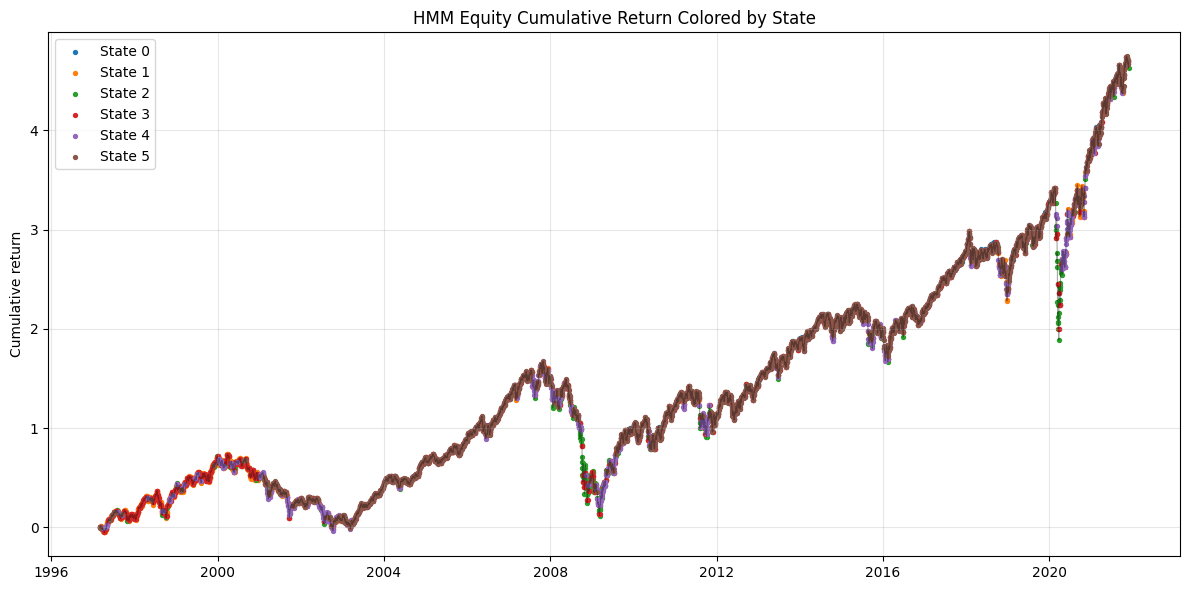

In [66]:
plot_regime_colored_series(cum_returns, hmm_labels, column="Equity");


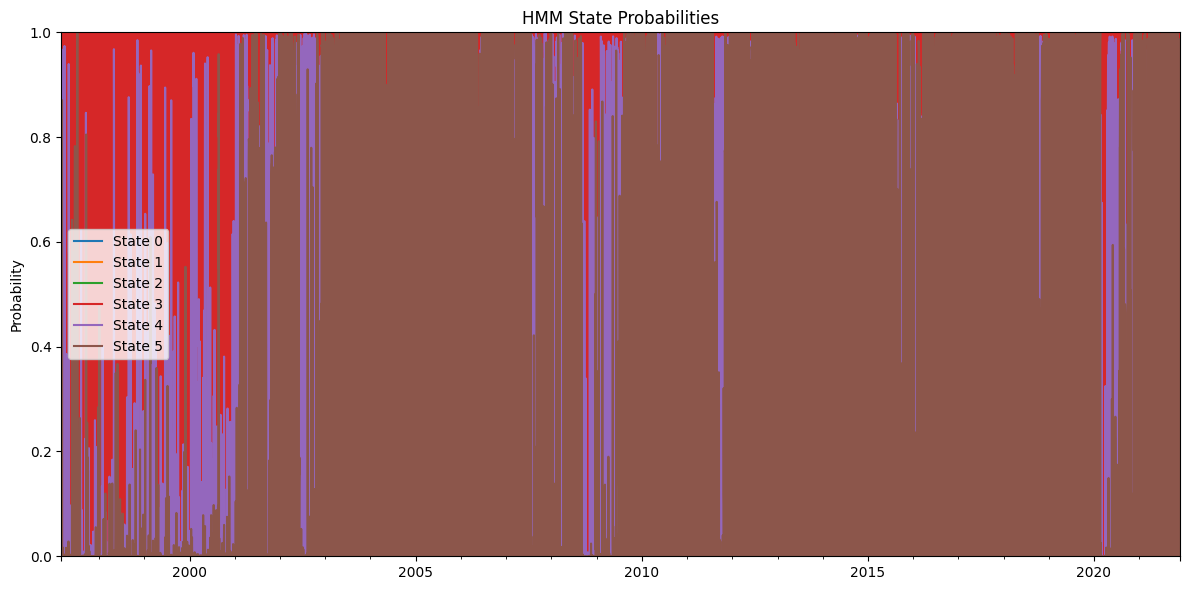

In [67]:
plot_regime_probabilities(hmm_probabilities);


In [68]:
rows = []
for state in sorted(hmm_labels.unique()):
    state_returns = raw_factor_returns.loc[hmm_labels == state]
    annual_return = state_returns.mean() * ANNUALIZATION
    annual_volatility = state_returns.std() * np.sqrt(ANNUALIZATION)
    annual_sharpe = annual_return / annual_volatility.replace(0, np.nan)
    corr = state_returns.corr()
    mask = ~np.eye(corr.shape[0], dtype=bool)

    rows.append({
        "Regime": state,
        "Frequency": len(state_returns) / len(raw_factor_returns),
        "AvgCorrelation": corr.where(mask).stack().mean(),
        **{f"{col}_Return": annual_return[col] for col in raw_factor_returns.columns},
        **{f"{col}_Volatility": annual_volatility[col] for col in raw_factor_returns.columns},
        **{f"{col}_Sharpe": annual_sharpe[col] for col in raw_factor_returns.columns},
    })

hmm_summary = pd.DataFrame(rows).set_index("Regime")
# hmm_summary.to_csv(OUTPUT_DIR / "hmm_raw_return_state_summary.csv")
compact_interpretation_table(hmm_summary).round(4)


,Frequency,AvgCorrelation,Equity_Return,Credit_Return,Commodities_Return,Equity_Volatility,Equity_Sharpe
Regime,,,,,,,
0,0.0611,0.1951,0.3009,0.1119,0.1635,0.0419,7.1893
1,0.1196,0.1734,0.0590,0.1101,0.0378,0.1597,0.3693
2,0.0439,0.2647,-0.8990,-0.0917,-1.1879,0.4926,-1.8249
3,0.2865,0.2441,0.0000,0.0000,0.0000,0.0000,0.6224
4,0.0770,0.1948,-0.0494,0.0316,0.1986,0.2239,-0.2206
5,0.4119,0.2680,0.2128,0.1014,0.2174,0.1245,1.7091


In [69]:
hmm_means = pd.DataFrame(hmm.means_, columns=scaled_returns.columns)
hmm_means.index.name = "HiddenState"
hmm_means.round(3)


,Equity,Interest_Rate,Credit,Commodities,Emerging_Market,Foreign_Currency,Local_Inflation,Local_Equity
HiddenState,,,,,,,,
0,0.075,0.013,0.050,0.026,0.133,0.069,0.001,0.039
1,-0.046,0.045,0.063,-0.050,-0.109,-0.077,0.030,-0.032
2,-0.285,0.140,-0.196,-0.236,-0.391,-0.158,0.000,-0.143
3,-0.023,-0.049,-0.071,-0.014,-0.023,-0.031,-0.054,-0.030
4,0.004,-0.011,-0.004,0.058,0.106,-0.001,0.032,0.003
5,0.053,0.004,0.049,0.039,0.057,0.053,0.023,0.041


## HMM Transition Diagnostics


In [70]:
hmm_transition_counts = transition_matrix(hmm_labels, n_regimes=N_COMPONENTS, normalize=False)
hmm_transition_probabilities = transition_matrix(hmm_labels, n_regimes=N_COMPONENTS, normalize=True)
hmm_durations = regime_duration_stats(hmm_labels)
hmm_performance = regime_performance_summary(raw_factor_returns, hmm_labels, annualization=ANNUALIZATION)

display(hmm_transition_counts.astype(int))
display(hmm_transition_probabilities.round(3))


To,0,1,2,3,4,5
From,,,,,,
0,96,4,5,123,0,324
1,5,738,40,151,133,14
2,2,23,170,83,100,18
3,205,313,114,1294,0,663
4,18,2,33,201,442,0
5,226,1,35,736,21,2703


To,0,1,2,3,4,5
From,,,,,,
0,0.174,0.007,0.009,0.223,0.000,0.587
1,0.005,0.683,0.037,0.140,0.123,0.013
2,0.005,0.058,0.429,0.210,0.253,0.045
3,0.079,0.121,0.044,0.500,0.000,0.256
4,0.026,0.003,0.047,0.289,0.635,0.000
5,0.061,0.000,0.009,0.198,0.006,0.726


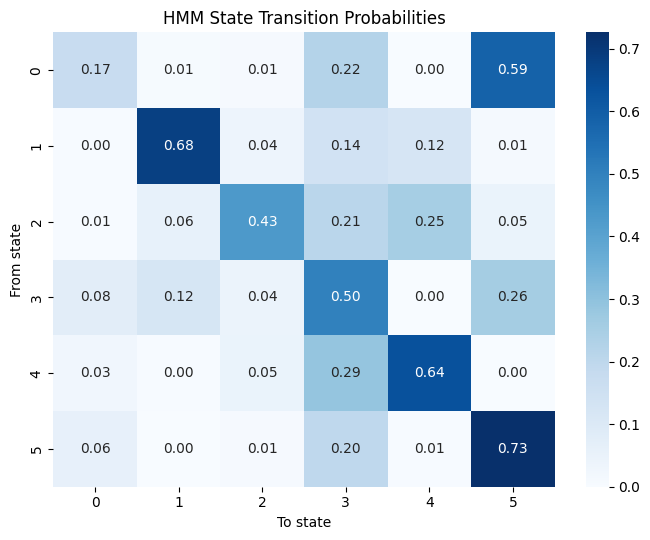

In [71]:
plot_transition_heatmap(
    hmm_transition_probabilities,
    title="HMM State Transition Probabilities",
    fmt=".2f",
    label_name="state",
);


In [72]:
hmm_durations.round(2)


,Count,Mean,Median,Min,Max
Regime,,,,,
0,456,1.21,1.0,1,5
1,343,3.15,3.0,1,5
2,227,1.75,1.0,1,5
3,1295,2.00,2.0,1,3
4,254,2.74,3.0,1,4
5,1019,3.65,4.0,1,5


In [73]:
hmm_performance.round(4)


,Regime,Factor,AnnualReturn,AnnualVolatility,Sharpe,Observations
0,0,Equity,0.3009,0.0419,7.1893,552
1,0,Interest_Rate,0.0788,0.0230,3.4247,552
2,0,Credit,0.1119,0.0169,6.6215,552
3,0,Commodities,0.1635,0.0829,1.9730,552
4,0,Emerging_Market,0.4326,0.0616,7.0222,552
5,0,Foreign_Currency,0.1864,0.0375,4.9652,552
6,0,Local_Inflation,0.0517,0.0207,2.4930,552
7,0,Local_Equity,0.2549,0.0445,5.7249,552
8,1,Equity,0.0590,0.1597,0.3693,1081
9,1,Interest_Rate,0.0983,0.0395,2.4889,1081


## GMM vs HMM Comparison


In [74]:
from src.analysis import label_confusion_matrix, persistence_table

label_confusion_matrix(labels, hmm_labels).astype(int)


HMM,0,1,2,3,4,5
GMM,,,,,,
0,0,13,206,0,3,0
1,1,0,0,2589,0,0
2,0,126,22,0,233,1762
3,549,113,0,0,29,1652
4,2,717,1,0,26,60
5,0,112,168,0,405,248


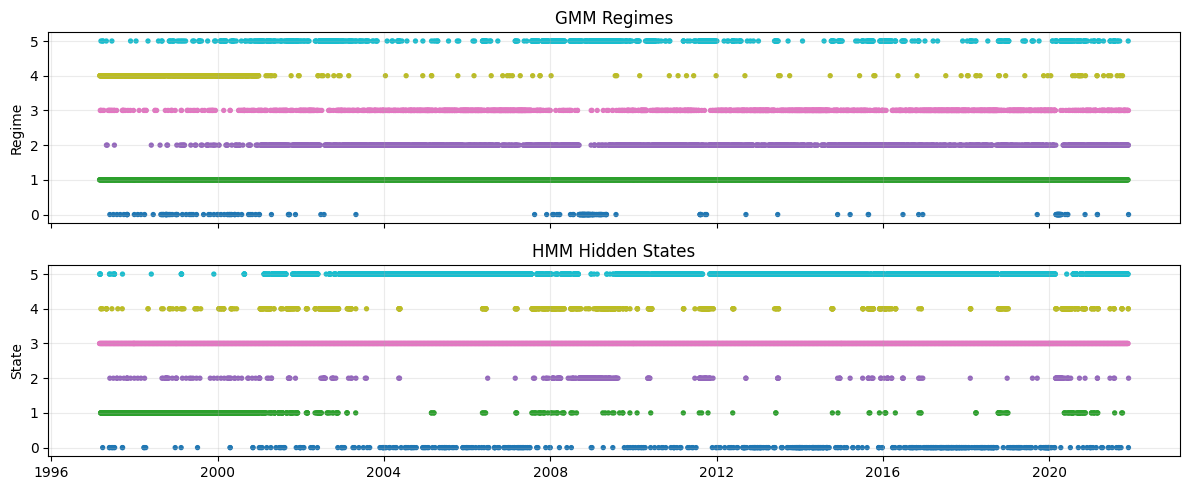

In [77]:
from src.analysis import label_confusion_matrix, persistence_table
from src.plots import plot_regime_timeline_comparison

plot_regime_timeline_comparison(labels, hmm_labels);

In [75]:
persistence_comparison = pd.DataFrame({
    "GMM": persistence_table(gmm_transition_probabilities)["Persistence"],
    "HMM": persistence_table(hmm_transition_probabilities)["Persistence"],
})
persistence_comparison.round(3)


,GMM,HMM
Regime,,
0,0.317,0.174
1,0.500,0.683
2,0.361,0.429
3,0.438,0.500
4,0.541,0.635
5,0.297,0.726


In [76]:
duration_comparison = pd.concat(
    [
        gmm_durations.add_prefix("GMM_"),
        hmm_durations.add_prefix("HMM_"),
    ],
    axis=1,
)
duration_comparison.round(2)


,GMM_Count,GMM_Mean,GMM_Median,GMM_Min,GMM_Max,HMM_Count,HMM_Mean,HMM_Median,HMM_Min,HMM_Max
Regime,,,,,,,,,,
0,152,1.46,1.0,1,5,456,1.21,1.0,1,5
1,1296,2.00,2.0,1,3,343,3.15,3.0,1,5
2,1370,1.56,1.0,1,5,227,1.75,1.0,1,5
3,1317,1.78,1.0,1,5,1295,2.00,2.0,1,3
4,370,2.18,1.0,1,5,254,2.74,3.0,1,4
5,656,1.42,1.0,1,5,1019,3.65,4.0,1,5


## Conclusions from Factor-Based Regime Model

Use `scaled_returns` only for model fitting. Use `raw_factor_returns` for regime interpretation, return/volatility tables, correlations by regime, and economic labels.
